<a href="https://colab.research.google.com/github/Pankajtanwar2005/dl-lab/blob/main/dl_lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pankaj
1/23/SET/BCS/421
6AIMLB1
DATE: 02/04/2026
EXPERIMENT: 10

In [ ]:
!pip uninstall rsa -y
!pip install rsa

import os
os.kill(os.getpid(), 9)   # restart runtime automatically

iris dataset

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 1, 1, 32)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,771 (18.64 KB)

 Trainable params: 4,771 (18.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3519 - loss: 1.0655 - val_accuracy: 0.1667 - val_loss: 1.1152
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3519 - loss: 1.0447 - val_accuracy: 0.1667 - val_loss: 1.0989
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.3704 - loss: 1.0241 - val_accuracy: 0.1667 - val_loss: 1.0829
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3889 - loss: 1.0037 - val_accuracy: 0.3333 - val_loss: 1.0673
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.5370 - loss: 0.9837 - val_accuracy: 0.5000 - val_loss: 1.0518
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.6204 - loss: 0.9640 - val_accuracy: 0.5000 - val_loss: 1.0366
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6389 - loss: 0.9446 - val_accuracy: 0.5000 - val_loss: 1.0218
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6667 - loss: 0.9254 - val_accuracy: 0.6667 - val_loss: 1.00

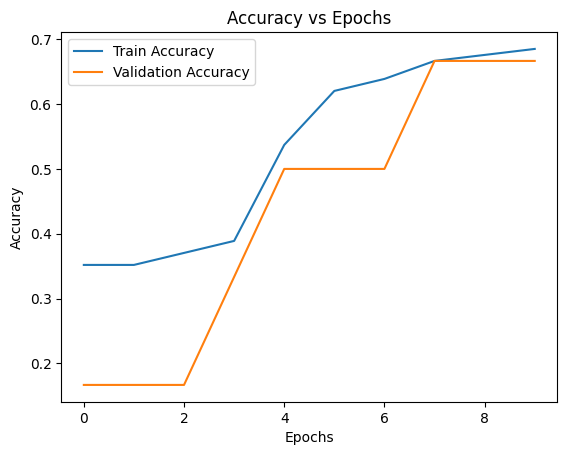

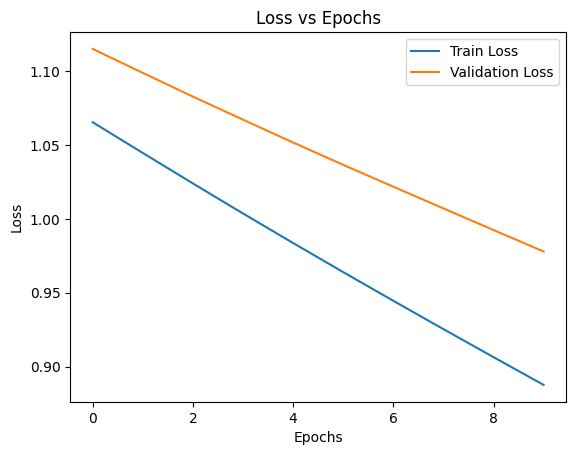

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert to "image" shape (2x2x1)
X = X.reshape(-1, 2, 2, 1)

# One-hot encode labels
y = to_categorical(y, 3)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build CNN model
model = Sequential([
    Conv2D(32, (2,2), activation='relu', input_shape=(2,2,1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Summary
model.summary()

# Train (STORE HISTORY)
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)

# =========================
# 📊 PLOT GRAPHS
# =========================

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()


Binary Classification using Dogs and Cats datset


Found 20557 images belonging to 3 classes.
Found 5138 images belonging to 3 classes.


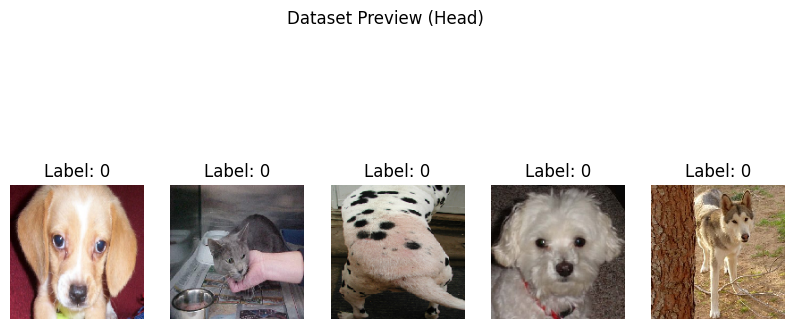

Class indices: {'PetImages': 0, 'test': 1, 'train': 2}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 942s 1s/step - accuracy: 0.9714 - loss: 0.1952 - val_accuracy: 0.9729 - val_loss: 0.1425
Epoch 2/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 913s 1s/step - accuracy: 0.9728 - loss: 0.1394 - val_accuracy: 0.9729 - val_loss: 0.1356
Epoch 3/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.9688 - loss: 0.1214 - val_accuracy: 0.9726 - val_loss: 0.1724
Epoch 4/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 898s 1s/step - accuracy: 0.9615 - loss: 0.1002 - val_accuracy: 0.9694 - val_loss: 0.1474
Epoch 5/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 932s 1s/step - accuracy: 0.9586 - loss: 0.0513 - val_accuracy: 0.9669 - val_loss: 0.1404
Epoch 6/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 906s 1s/step - accuracy: 0.9568 - loss: -0.0360 - val_accuracy: 0.9644 - val_loss: 0.1784
Epoch 7/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 910s 1s/step - accuracy: 0.9461 - loss: -0.4063 - val_accuracy: 0.9366 - val_loss: 0.2708
Epoch 8/10
643/643 ━━━━━━━━━━━━━━━━━━━━ 944s 1s/step - accuracy: 0.9480 - loss: -2.9651 - val_a

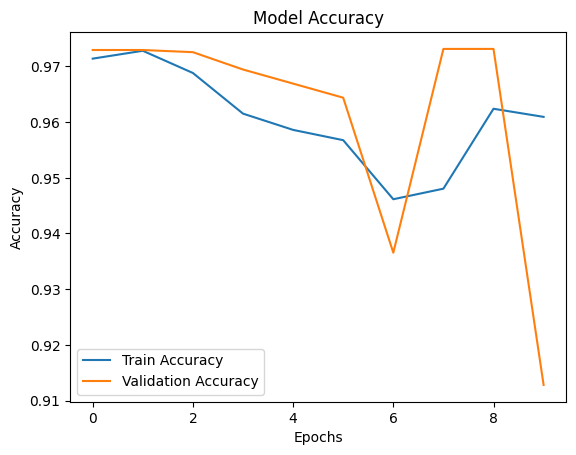

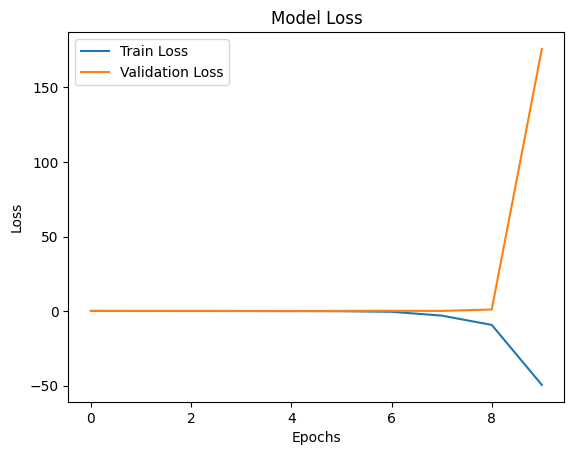

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import zipfile
import os

# -------------------------------
# 📁 Dataset Path (Change if needed)
# -------------------------------
zip_path = "/content/archive (3).zip"
extraction_dir = '/content/dataset'

# Create the extraction directory if it doesn't exist
if not os.path.exists(extraction_dir):
    os.makedirs(extraction_dir)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

# Now, train_dir should point to the extracted dataset directory
train_dir = extraction_dir

# -------------------------------
# 🔄 Image Preprocessing
# -------------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Training Data
train_data = datagen.flow_from_directory(
    train_dir,
      target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation Data
val_data = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# -------------------------------
# 📊 DATASET PREVIEW (HEAD)
# -------------------------------
images, labels = next(train_data)

plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])}")
    plt.axis('off')

plt.suptitle("Dataset Preview (Head)")
plt.show()

# Show class labels
print("Class indices:", train_data.class_indices)

# -------------------------------
# 🧠 CNN MODEL
# -------------------------------
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
      Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')

])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 🚀 TRAIN MODEL
# -------------------------------
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

# -------------------------------
# 📊 GRAPHS
# -------------------------------

# Accuracy Graph
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()

# Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

